# TSAI SS2025 Exercise Sheet 9 - Template Code

In [1]:
# import os
# os.environ["OMP_NUM_THREADS"] = "4" # limit numpy threads if needed.
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

## 1 Reservoir computing

1.1 Implement the ESN class

In [2]:
class ESN:
    def __init__(self, N, M, alpha, beta, sigma, rho):
        # observation space dimensionality
        self.N = N
        # reservoir size
        self.M = M
        self.alpha = alpha
        self.beta = beta
        self.sigma = sigma
        self.rho = rho

        # draw W_in from Gaussian distribution with mean 0 and variance sigma^2
        self.W_in = np.random.randn(self.M, self.N) * self.sigma

        # draw b from Gaussian distribution with mean 0 and variance beta^2
        self.b = np.random.randn(self.M) * self.beta

        # draw W randomly and renormalize to have spectral radius rho
        W = np.random.randn(self.M, self.M)
        self.W = W / np.max(np.abs(np.linalg.eigvals(W))) * self.rho

        # output weights (will be overwritten by training)
        self.W_out = None

    def forward(self, x, r):
        """Forward pass of the ESN. Implements the state equation.

        Args:
            x (np.ndarray): Input data (1D array, N)
            r (np.ndarray): Reservoir state (1D array, M)

        Returns:
            np.ndarray: Next reservoir state (1D array, M)
        """
        # your code here
        r_t = (1 - self.alpha)*r + self.alpha*np.tanh(self.W@r + self.W_in@x + self.b)
        return r_t

    def __call__(self, x, r):
        return self.forward(x, r)

    def drive(self, X):
        """Drive the ESN with input X.

        Args:
            X (np.ndarray): Input data (2D array, T x N)

        Returns:
            np.ndarray: Reservoir states (2D array, T x M)
        """
        # your code here
        T = X.shape[0]
        R = np.zeros((T, self.M))
        r = np.zeros(self.M)
        for i, x in enumerate(X):
            r = self.forward(X[i], r)
            R[i] = r
            
        return R
        

    def train(self, X, Y, ridge_lambda, t_trans=1000):
        """Compute the output weights using ridge regression. Store the output weights in self.W_out.

        Args:
            X (np.ndarray): Input data (2D array, T x N)
            Y (np.ndarray): Target data (2D array, T x N)
            ridge_lambda (float): Ridge regression parameter
            t_trans (int, optional): Number of transient steps to discard.

        Returns:
            float: Training error
        """
        # drive the ESN with input X
        R = self.drive(X)
        T = X.shape[0]

        # discard transient steps
        R_ = R[t_trans:, :]
        Y_ = Y[t_trans:, :]

        # compute the output weights using ridge regression -> (N x M) output weights
        I = np.eye(self.M)
        self.W_out = Y_.T @ R_ @ np.linalg.inv(R_.T@R_ + ridge_lambda*I) # your code here

        # compute the training error using fittet W_out
        L_RR = np.mean((Y_ - R_@self.W_out.T)**2) # your code here
        return L_RR

    def generate(self, X, T_gen):
        """Generate data from the ESN.

        Args:
            X (np.ndarray): Input data (2D array, T x N)
            T_gen (int): Number of steps to generate

        Returns:
            np.ndarray: Generated data in the observation space (2D array, T_gen x N)
        """
        # your code here
        # Warm up reservoir
        R = self.drive(X)
        r = R[-1].copy()
        Y_gen = np.zeros((T_gen, self.N))
    
        # Generate
        x_prev = X[-1]
        for t in range(T_gen):
            r = self.forward(x_prev, r)
            y = self.W_out @ r
    
            Y_gen[t] = y
            x_prev = y
    
        return Y_gen
            

1.2 Train and generate data, validate the model

In [3]:
data = np.load("lorenz_data.npy")
print(data.shape)

T_train = 10000 # use first 10000 data points for training

# split data into input (driving) and target data
X = data[:T_train, :]
Y = data[1 : T_train + 1, :]

(20000, 3)


In [4]:
# hypers
N = 3
M = 500
alpha = 0.6
beta = 0.7
sigma = 0.3
rho = 0.75
ridge_lambda = 1e-2

In [10]:
# initialize ESN
esn = ESN(N, M, alpha, beta, sigma, rho)

# train ESN
loss = esn.train(X, Y, ridge_lambda)
print(loss)

# generate data using trained ESN
X_drive = X[:1000, :]
X_gen = esn.generate(X_drive, data.shape[0])

0.0009566285821387541


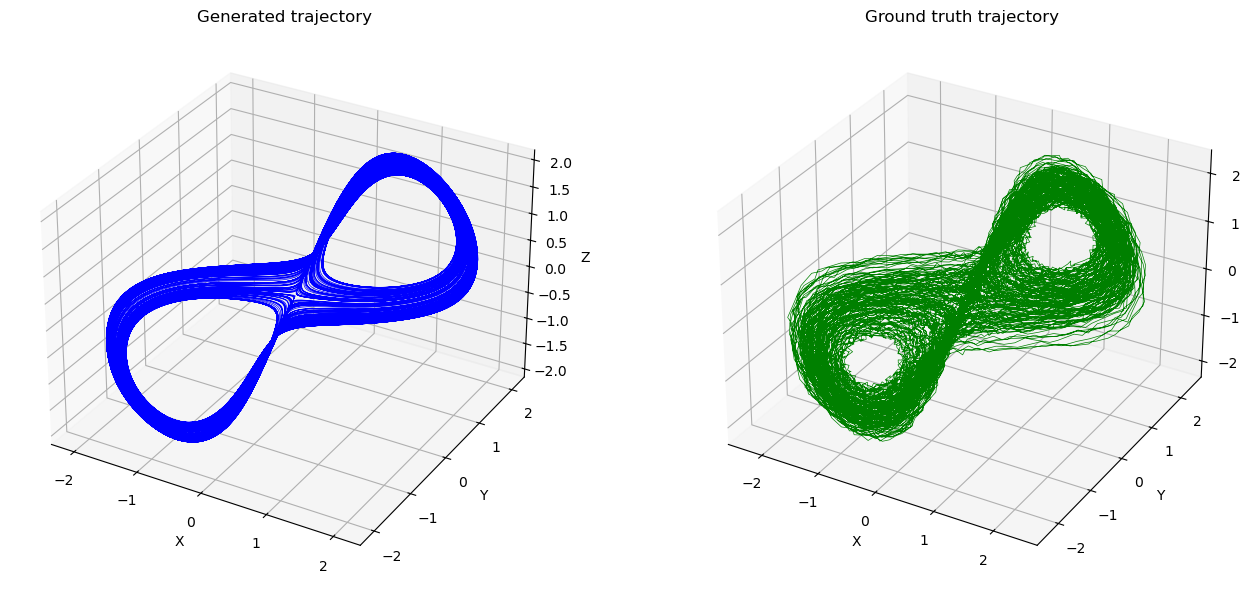

In [15]:
# plot trajectories of respective models (plot 3d, use subplots)
# your code here
x, y, z = X_gen[:, 0], X_gen[:, 1], X_gen[:, 2]
x_og, y_og, z_og = data[:, 0], data[:, 1], data[:, 2]

# Plot
fig = plt.figure(figsize=(14, 6))

# Plot groud truth
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.plot(x_og, y_og, z_og, lw=0.5, color='green')
ax1.set_title('Ground truth trajectory')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot generated trajectory
ax2 = fig.add_subplot(1, 2, 1, projection='3d')
ax2.plot(x, y, z, lw=0.5, color='blue')
ax2.set_title('Generated trajectory')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

1.3 Line search across latent dimension

In [21]:
# your code here
def train_model(M):
    
    # initialize ESN
    esn = ESN(N, M, alpha, beta, sigma, rho)
    
    # train ESN
    loss = esn.train(X, Y, ridge_lambda)
    print(loss)
    
    # generate data using trained ESN
    X_drive = X[:1000, :]
    X_gen = esn.generate(X_drive, data.shape[0])

    return X_gen
    
Ms = [400, 300, 200, 100, 50]
X_gens = []

for M in Ms:

    results = []
    
    for i in range(5):

        X_gen = train_model(M)
        results.append(X_gen)

    X_gens.append(results)

0.0009614917144106951
0.0009626252603761361
0.0009603776802930286
0.0009626334904695958
0.0009607267989268809
0.0009622553572846531
0.0009679933275486634
0.000967856092137784
0.0009697883403302369
0.0009707791094855939
0.0009795184391076866
0.0009791196389694918
0.0009886913711226
0.0009825302417529175
0.0009800661491410317
0.001024426610805586
0.0010147966516502324
0.001022087744279257
0.001008361438359472
0.0010144012100529608
0.0010783417326749687
0.0010697724859357837
0.001083960756216264
0.0010929096083955388
0.001087211389599171


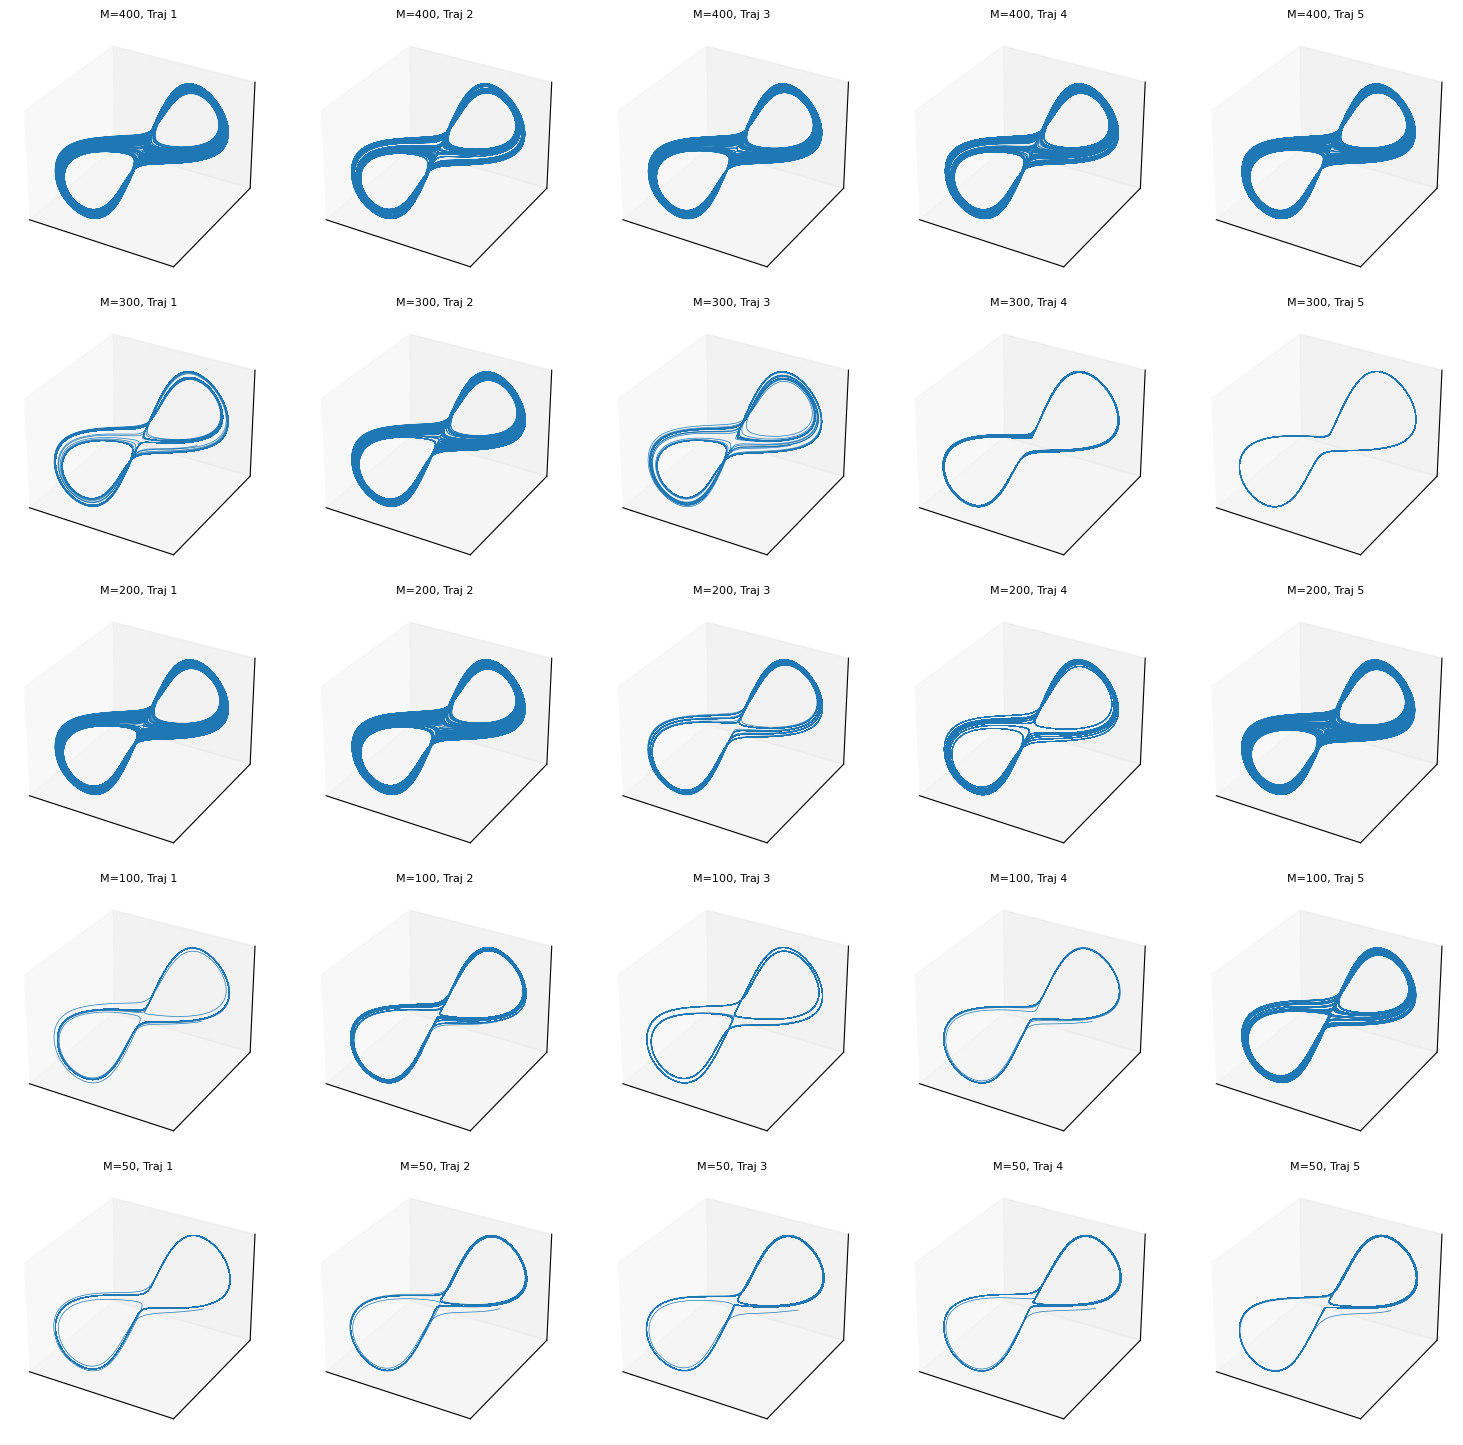

In [24]:
# Plot
fig = plt.figure(figsize=(15, 15))
for i, (M_val, traj_group) in enumerate(zip(Ms, X_gens)):
    for j, traj in enumerate(traj_group):
        ax = fig.add_subplot(5, 5, i * 5 + j + 1, projection='3d')
        x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]
        ax.plot(x, y, z, lw=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.set_title(f"M={M_val}, Traj {j+1}", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

For lower M values the results deteriorate significantly. Also there seems to be a higher variability in the results for different models. Whereas with M=500 all results look good, for lower Ms there are some results that look good and other that dont. 